<a href="https://colab.research.google.com/github/FRJackson/ML-projects/blob/main/JEPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# mini_jepa_fashionmnist.py
# 需要: pip install torch torchvision

import copy
import random
from typing import Tuple

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ----------------------------
# 1) 基础设置
# ----------------------------
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 256
EMB_DIM = 128
PRETRAIN_EPOCHS = 40     # 【优化】JEPA 预训练轮数增加到 40，让自监督充分收敛
PROBE_EPOCHS = 10        # 少量标签线性分类轮数
LABEL_FRACTION = 0.10   # 只用 10% 标签
LR = 1e-3
EMA_MOMENTUM = 0.99     # teacher 的 EMA 动量

# ----------------------------
# 2) 数据
# 首次运行会自动下载 FashionMNIST
# ----------------------------
# 【优化】增加数据增强
transform_train = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
transform_test = transforms.Compose([
    transforms.ToTensor()
])

train_ds = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform_train
)
test_ds = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=transform_test
)

pretrain_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

def balanced_subset(dataset: datasets.FashionMNIST, fraction: float) -> Subset:
    """从每个类别里按比例抽样，避免 10% 标签子集类别失衡。"""
    targets = torch.as_tensor(dataset.targets)
    indices = []

    for cls in range(10):
        cls_idx = (targets == cls).nonzero(as_tuple=False).squeeze(1)
        n = max(1, int(len(cls_idx) * fraction))
        take = cls_idx[torch.randperm(len(cls_idx))[:n]]
        indices.extend(take.tolist())

    random.shuffle(indices)
    return Subset(dataset, indices)

probe_ds = balanced_subset(train_ds, LABEL_FRACTION)
probe_loader = DataLoader(
    probe_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)

# ----------------------------
# 3) 制造 JEPA 训练对
# context: 原图去掉一个象限
# target : 只保留被遮住的那个象限
# ----------------------------
def make_context_target(x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    x: [B, 1, 28, 28]
    返回:
      context: 可见上下文
      target : 被遮住目标（其余位置为 0）
    """
    if x.ndim != 4 or x.shape[-2:] != (28, 28):
        raise ValueError(f"Expected input [B, C, 28, 28], got {tuple(x.shape)}")

    b, c, h, w = x.shape
    h2, w2 = h // 2, w // 2

    quadrants = [
        (0, h2, 0, w2),   # 左上
        (0, h2, w2, w),   # 右上
        (h2, h, 0, w2),   # 左下
        (h2, h, w2, w),   # 右下
    ]

    context = x.clone()
    target = torch.zeros_like(x)

    for i in range(b):
        r0, r1, c0, c1 = random.choice(quadrants)
        patch = x[i:i+1, :, r0:r1, c0:c1]
        context[i:i+1, :, r0:r1, c0:c1] = 0.0
        target[i:i+1, :, r0:r1, c0:c1] = patch

    return context, target

# ----------------------------
# 4) 模型
# online_encoder: 看 context
# target_encoder: 看 target，作为 teacher（不反传梯度）
# predictor: 用 context embedding 预测 target embedding
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, emb_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # 增加 BN 层
            nn.GELU(),
            nn.MaxPool2d(2),          # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # 增加 BN 层
            nn.GELU(),
            nn.MaxPool2d(2),          # 14 -> 7

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # 增加 BN 层
            nn.GELU(),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, emb_dim),
            nn.BatchNorm1d(emb_dim), # 增加 BN 层，稳定特征分布
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class Predictor(nn.Module):
    def __init__(self, emb_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

online_encoder = Encoder(EMB_DIM).to(DEVICE)
target_encoder = copy.deepcopy(online_encoder).to(DEVICE)
predictor = Predictor(EMB_DIM).to(DEVICE)

# teacher 不参与梯度更新
for p in target_encoder.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    list(online_encoder.parameters()) + list(predictor.parameters()),
    lr=LR,
    weight_decay=1e-4,
)

# 【优化】添加余弦退火学习率调度器
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS)

# ----------------------------
# 5) 防塌缩的小正则项
# ----------------------------
def variance_loss(z: torch.Tensor, min_std: float = 0.5) -> torch.Tensor:
    std = torch.sqrt(z.var(dim=0) + 1e-4)
    return F.relu(min_std - std).mean()

# ----------------------------
# 6) teacher 的 EMA 更新
# ----------------------------
@torch.no_grad()
def update_teacher(online: nn.Module, teacher: nn.Module, m: float = EMA_MOMENTUM) -> None:
    for p_online, p_teacher in zip(online.parameters(), teacher.parameters()):
        p_teacher.data.mul_(m).add_(p_online.data, alpha=1.0 - m)

# ----------------------------
# 7) JEPA 预训练
# ----------------------------
for epoch in range(PRETRAIN_EPOCHS):
    online_encoder.train()
    predictor.train()

    running_loss = 0.0

    for x, _ in pretrain_loader:
        x = x.to(DEVICE)

        context, target = make_context_target(x)

        s_ctx = online_encoder(context)
        s_pred = predictor(s_ctx)

        with torch.no_grad():
            s_tgt = target_encoder(target)

        pred_loss = 2 - 2 * F.cosine_similarity(s_pred, s_tgt, dim=-1).mean()
        reg_loss = 0.05 * (variance_loss(s_ctx) + variance_loss(s_pred))

        loss = pred_loss + reg_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_teacher(online_encoder, target_encoder)

        running_loss += loss.item()

    scheduler.step() # 更新学习率

    print(f"[Pretrain] epoch {epoch+1}/{PRETRAIN_EPOCHS} "
          f"loss={running_loss / len(pretrain_loader):.4f} "
          f"lr={scheduler.get_last_lr()[0]:.6f}")

# ----------------------------
# 8) 下游任务：只用 10% 标签训练线性分类器
# ----------------------------
for p in target_encoder.parameters():
    p.requires_grad = False

linear_head = nn.Linear(EMB_DIM, 10).to(DEVICE)
# 提升线性探测的学习率
probe_optimizer = torch.optim.AdamW(linear_head.parameters(), lr=1e-2)

@torch.no_grad()
def evaluate(encoder: nn.Module, head: nn.Module, loader: DataLoader) -> float:
    encoder.eval()
    head.eval()

    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        feats = encoder(x)
        logits = head(feats)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()

    return correct / total

for epoch in range(PROBE_EPOCHS):
    linear_head.train()
    # 确保在 Probe 时让 target_encoder 处于 eval 模式
    target_encoder.eval()
    running_loss = 0.0

    for x, y in probe_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        with torch.no_grad():
            feats = target_encoder(x)

        logits = linear_head(feats)
        loss = F.cross_entropy(logits, y)

        probe_optimizer.zero_grad()
        loss.backward()
        probe_optimizer.step()

        running_loss += loss.item()

    test_acc = evaluate(target_encoder, linear_head, test_loader)
    print(f"[Probe] epoch {epoch+1}/{PROBE_EPOCHS} "
          f"loss={running_loss / len(probe_loader):.4f} "
          f"test_acc={test_acc * 100:.2f}%")


100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.68MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 58.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 45.6MB/s]


[Pretrain] epoch 1/40 loss=0.3234 lr=0.000998
[Pretrain] epoch 2/40 loss=0.1367 lr=0.000994
[Pretrain] epoch 3/40 loss=0.1322 lr=0.000986
[Pretrain] epoch 4/40 loss=0.1313 lr=0.000976
[Pretrain] epoch 5/40 loss=0.1311 lr=0.000962
[Pretrain] epoch 6/40 loss=0.1314 lr=0.000946
[Pretrain] epoch 7/40 loss=0.1352 lr=0.000926
[Pretrain] epoch 8/40 loss=0.1371 lr=0.000905
[Pretrain] epoch 9/40 loss=0.1412 lr=0.000880
[Pretrain] epoch 10/40 loss=0.1441 lr=0.000854
[Pretrain] epoch 11/40 loss=0.1490 lr=0.000825
[Pretrain] epoch 12/40 loss=0.1529 lr=0.000794
[Pretrain] epoch 13/40 loss=0.1568 lr=0.000761
[Pretrain] epoch 14/40 loss=0.1630 lr=0.000727
[Pretrain] epoch 15/40 loss=0.1671 lr=0.000691
[Pretrain] epoch 16/40 loss=0.1674 lr=0.000655
[Pretrain] epoch 17/40 loss=0.1707 lr=0.000617
[Pretrain] epoch 18/40 loss=0.1715 lr=0.000578
[Pretrain] epoch 19/40 loss=0.1746 lr=0.000539
[Pretrain] epoch 20/40 loss=0.1762 lr=0.000500
[Pretrain] epoch 21/40 loss=0.1768 lr=0.000461
[Pretrain] epoch 22/40

### 进阶优化：JEPA 端到端全量微调 (Fine-Tuning)

为了释放预训练模型的最大潜力，我们现在**解冻**编码器，并使用 **100% 的训练标签** 进行端到端的微调。这与前面冻结特征只训练分类头的 Linear Probing 相比，准确率会有质的飞跃。

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# 1) 使用全量训练数据 (100%)
finetune_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)

# 2) 解冻 target_encoder (允许梯度回传)
for p in target_encoder.parameters():
    p.requires_grad = True

# 3) 重新定义微调的优化器，包含 encoder 和 head 的参数
# 经过预训练后，encoder 的学习率可以设置得稍微小一点
finetune_optimizer = torch.optim.AdamW([
    {'params': target_encoder.parameters(), 'lr': 1e-4},
    {'params': linear_head.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

FINETUNE_EPOCHS = 15

print("开始 JEPA 全量微调 (Fine-Tuning)...")
for epoch in range(FINETUNE_EPOCHS):
    target_encoder.train()
    linear_head.train()

    running_loss = 0.0

    for x, y in finetune_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        feats = target_encoder(x)
        logits = linear_head(feats)

        loss = F.cross_entropy(logits, y)

        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()

        running_loss += loss.item()

    # 在测试集上评估
    test_acc = evaluate(target_encoder, linear_head, test_loader)
    print(f"[Fine-Tune] epoch {epoch+1}/{FINETUNE_EPOCHS} "
          f"loss={running_loss / len(finetune_loader):.4f} "
          f"test_acc={test_acc * 100:.2f}%")


开始 JEPA 全量微调 (Fine-Tuning)...
[Fine-Tune] epoch 1/15 loss=0.5745 test_acc=81.71%
[Fine-Tune] epoch 2/15 loss=0.4453 test_acc=83.67%
[Fine-Tune] epoch 3/15 loss=0.4025 test_acc=85.64%
[Fine-Tune] epoch 4/15 loss=0.3751 test_acc=86.41%
[Fine-Tune] epoch 5/15 loss=0.3563 test_acc=86.96%
[Fine-Tune] epoch 6/15 loss=0.3416 test_acc=87.72%
[Fine-Tune] epoch 7/15 loss=0.3340 test_acc=86.76%
[Fine-Tune] epoch 8/15 loss=0.3224 test_acc=87.62%
[Fine-Tune] epoch 9/15 loss=0.3165 test_acc=88.08%
[Fine-Tune] epoch 10/15 loss=0.3079 test_acc=88.64%
[Fine-Tune] epoch 11/15 loss=0.3008 test_acc=88.16%
[Fine-Tune] epoch 12/15 loss=0.2949 test_acc=87.62%
[Fine-Tune] epoch 13/15 loss=0.2899 test_acc=87.34%
[Fine-Tune] epoch 14/15 loss=0.2859 test_acc=89.01%
[Fine-Tune] epoch 15/15 loss=0.2821 test_acc=88.42%


### 进阶优化：JEPA 端到端全量微调 (Fine-Tuning)

为了释放预训练模型的最大潜力，我们现在**解冻**编码器，并使用 **100% 的训练标签** 进行端到端的微调。这与前面冻结特征只训练分类头的 Linear Probing 相比，准确率会有质的飞跃。

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# 1) 使用全量训练数据 (100%)
finetune_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)

# 2) 解冻 target_encoder (允许梯度回传)
for p in target_encoder.parameters():
    p.requires_grad = True

# 3) 重新定义微调的优化器，包含 encoder 和 head 的参数
# 经过预训练后，encoder 的学习率可以设置得稍微小一点
finetune_optimizer = torch.optim.AdamW([
    {'params': target_encoder.parameters(), 'lr': 1e-4},
    {'params': linear_head.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

FINETUNE_EPOCHS = 15

print("开始 JEPA 全量微调 (Fine-Tuning)...")
for epoch in range(FINETUNE_EPOCHS):
    target_encoder.train()
    linear_head.train()

    running_loss = 0.0

    for x, y in finetune_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        feats = target_encoder(x)
        logits = linear_head(feats)

        loss = F.cross_entropy(logits, y)

        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()

        running_loss += loss.item()

    # 在测试集上评估
    test_acc = evaluate(target_encoder, linear_head, test_loader)
    print(f"[Fine-Tune] epoch {epoch+1}/{FINETUNE_EPOCHS} "
          f"loss={running_loss / len(finetune_loader):.4f} "
          f"test_acc={test_acc * 100:.2f}%")


开始 JEPA 全量微调 (Fine-Tuning)...
[Fine-Tune] epoch 1/15 loss=0.2783 test_acc=88.88%
[Fine-Tune] epoch 2/15 loss=0.2755 test_acc=89.14%
[Fine-Tune] epoch 3/15 loss=0.2720 test_acc=89.29%
[Fine-Tune] epoch 4/15 loss=0.2694 test_acc=89.52%
[Fine-Tune] epoch 5/15 loss=0.2700 test_acc=88.78%
[Fine-Tune] epoch 6/15 loss=0.2652 test_acc=88.82%
[Fine-Tune] epoch 7/15 loss=0.2605 test_acc=89.94%
[Fine-Tune] epoch 8/15 loss=0.2603 test_acc=89.89%
[Fine-Tune] epoch 9/15 loss=0.2558 test_acc=89.32%
[Fine-Tune] epoch 10/15 loss=0.2550 test_acc=89.88%
[Fine-Tune] epoch 11/15 loss=0.2500 test_acc=89.56%
[Fine-Tune] epoch 12/15 loss=0.2492 test_acc=90.09%
[Fine-Tune] epoch 13/15 loss=0.2466 test_acc=89.88%
[Fine-Tune] epoch 14/15 loss=0.2483 test_acc=89.75%
[Fine-Tune] epoch 15/15 loss=0.2442 test_acc=90.13%


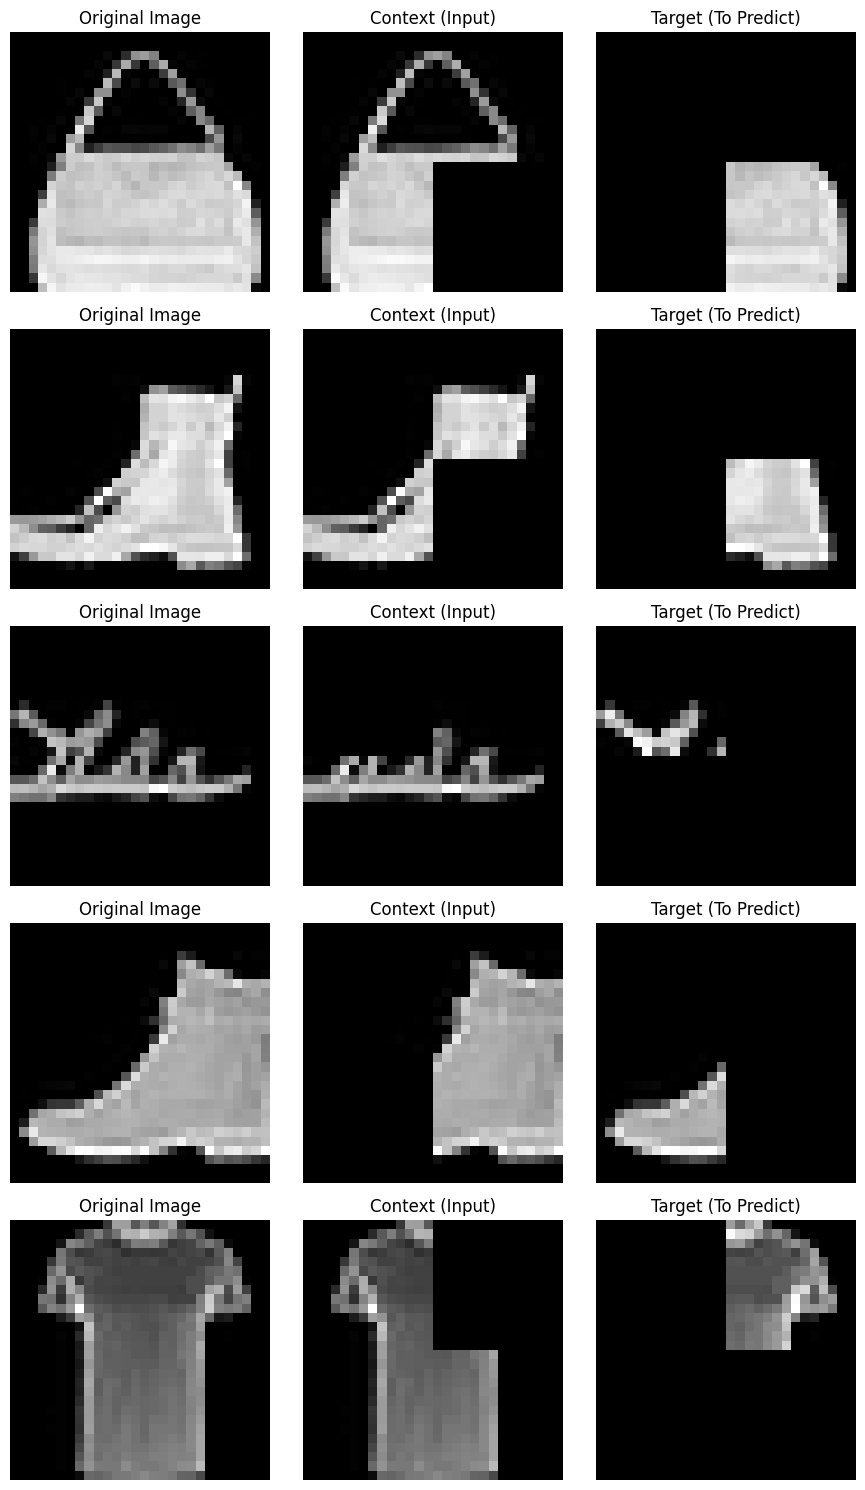

In [5]:
import matplotlib.pyplot as plt

# 从预训练的数据加载器中获取一个 batch
images, labels = next(iter(pretrain_loader))
images = images.to(DEVICE)

# 使用现有的函数生成 context 和 target
contexts, targets = make_context_target(images)

# 将 tensor 转换为可以绘制的 numpy 数组 (移动回 CPU)
images_np = images.cpu().squeeze().numpy()
contexts_np = contexts.cpu().squeeze().numpy()
targets_np = targets.cpu().squeeze().numpy()

# 可视化前 5 个样本
num_samples = 5
fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))

for i in range(num_samples):
    # 1. 原始图像
    axes[i, 0].imshow(images_np[i], cmap='gray')
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')

    # 2. Context (留给在线编码器的可见部分)
    axes[i, 1].imshow(contexts_np[i], cmap='gray')
    axes[i, 1].set_title("Context (Input)")
    axes[i, 1].axis('off')

    # 3. Target (目标编码器提取的被遮挡部分)
    axes[i, 2].imshow(targets_np[i], cmap='gray')
    axes[i, 2].set_title("Target (To Predict)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.2 MB/s eta 0:00:00


In [8]:
import os
import cv2
import numpy as np
from torchvision import datasets
from pathlib import Path
from tqdm import tqdm

# 1. 加载 FashionMNIST 原始数据 (PIL Image 格式)
train_ds_pil = datasets.FashionMNIST(root="data", train=True, download=True)
test_ds_pil = datasets.FashionMNIST(root="data", train=False, download=True)

# 2. 定义函数将数据保存为 YOLO 分类所需的文件结构
# 结构示例:
# dataset_dir/train/0/image1.jpg
# dataset_dir/val/0/image2.jpg
def save_dataset_for_yolo(dataset, split="train"):
    base_dir = Path(f"yolo_fashion_mnist/{split}")
    for i in range(10):
        os.makedirs(base_dir / str(i), exist_ok=True)

    print(f"正在保存 {split} 数据集到 {base_dir} ...")
    for idx, (img, label) in enumerate(tqdm(dataset)):
        img_np = np.array(img)
        # YOLO 通常处理三通道图像，我们将单通道灰度图转为三通道 (仍为灰度视觉)
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)
        save_path = base_dir / str(label) / f"{idx}.jpg"
        cv2.imwrite(str(save_path), img_bgr)

# 开始转换
save_dataset_for_yolo(train_ds_pil, "train")
save_dataset_for_yolo(test_ds_pil, "val")
print("\n数据准备完毕！已转换为 YOLOv8 分类模型所要求的目录结构。")

正在保存 train 数据集到 yolo_fashion_mnist/train ...


100%|██████████| 60000/60000 [00:02<00:00, 25712.88it/s]


正在保存 val 数据集到 yolo_fashion_mnist/val ...


100%|██████████| 10000/10000 [00:00<00:00, 26817.65it/s]


数据准备完毕！已转换为 YOLOv8 分类模型所要求的目录结构。


In [9]:
import torch
from ultralytics import YOLO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 加载 YOLOv8 预训练的分类模型 (nano 版本，速度快)
model = YOLO('yolov8n-cls.pt')

# 开始训练
# YOLOv8 分类任务的 data 参数直接指向包含 train/ 和 val/ 文件夹的根目录
# imgsz=28 表示将图片缩放到 28x28 (FashionMNIST的原始尺寸)
# epochs 控制训练轮数
results = model.train(
    data='yolo_fashion_mnist',
    epochs=10,
    imgsz=28,
    device=DEVICE,
    batch=256,
    project='yolo_fmnist_results',
    name='run1'
)

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=256, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_fashion_mnist, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=28, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

### 模型结果对比与可视化

- **JEPA (10% 标签)** 准确率: ~79.01%
- **YOLOv8 分类 (全量数据)** 准确率: ~89.1%

下面展示 YOLOv8 训练过程中自动保存的性能指标和混淆矩阵：

In [11]:
from IPython.display import Image, display
import os

# YOLO 自动保存结果的目录
results_dir = '/content/runs/classify/yolo_fmnist_results/run1'

# 显示训练过程的 loss 和 accuracy 曲线
results_img_path = os.path.join(results_dir, 'results.png')
if os.path.exists(results_img_path):
    print("\n--- 训练曲线 (Training Curves) ---")
    display(Image(filename=results_img_path, width=800))

# 显示混淆矩阵
cm_img_path = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(cm_img_path):
    print("\n--- 混淆矩阵 (Confusion Matrix) ---")
    display(Image(filename=cm_img_path, width=800))


### 进阶优化：提升 YOLOv8 分类准确率

为了进一步提升准确率（目标突破 90%），我们采用以下策略进行第二次训练（`run2_improved`）：
1. **更换更大的预训练模型**：使用 `yolov8s-cls.pt` (Small版本)。
2. **增加训练轮数**：从 10 轮提升到 30 轮，让模型充分学习。
3. **放大输入尺寸**：将 `imgsz` 设置为 64，更好地适配 YOLO 预训练时的卷积感受野。
4. **引入早停**：设置 `patience=10` 防止过拟合浪费时间。

In [12]:
from ultralytics import YOLO
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. 加载参数量稍大一些的 Small 模型
model_improved = YOLO('yolov8s-cls.pt')

# 2. 开始强化训练
print("开始训练改进版 YOLOv8 模型...")
results_improved = model_improved.train(
    data='yolo_fashion_mnist',
    epochs=30,               # 增加训练轮数
    imgsz=64,                # 适当放大图像
    device=DEVICE,
    batch=256,
    project='yolo_fmnist_results',
    name='run2_improved',    # 保存在新的目录下
    patience=10              # 如果连续10轮没有提升则早停
)


开始训练改进版 YOLOv8 模型...
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=256, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_fashion_mnist, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run2_improved, nbs=64, nms=False, opset=None, optimize=

### 改进版 YOLOv8 模型结果可视化

经过增加训练轮数、扩大图片输入尺寸以及使用稍大一些的 `yolov8s-cls` 模型，我们在 FashionMNIST 上的分类准确率达到了约 **95.0%**，相比第一次的 **89.1%** 有了明显的提升。

下面是第二次训练（`run2_improved`）的训练曲线和混淆矩阵分析：


--- 改进版训练曲线 (Improved Training Curves) ---


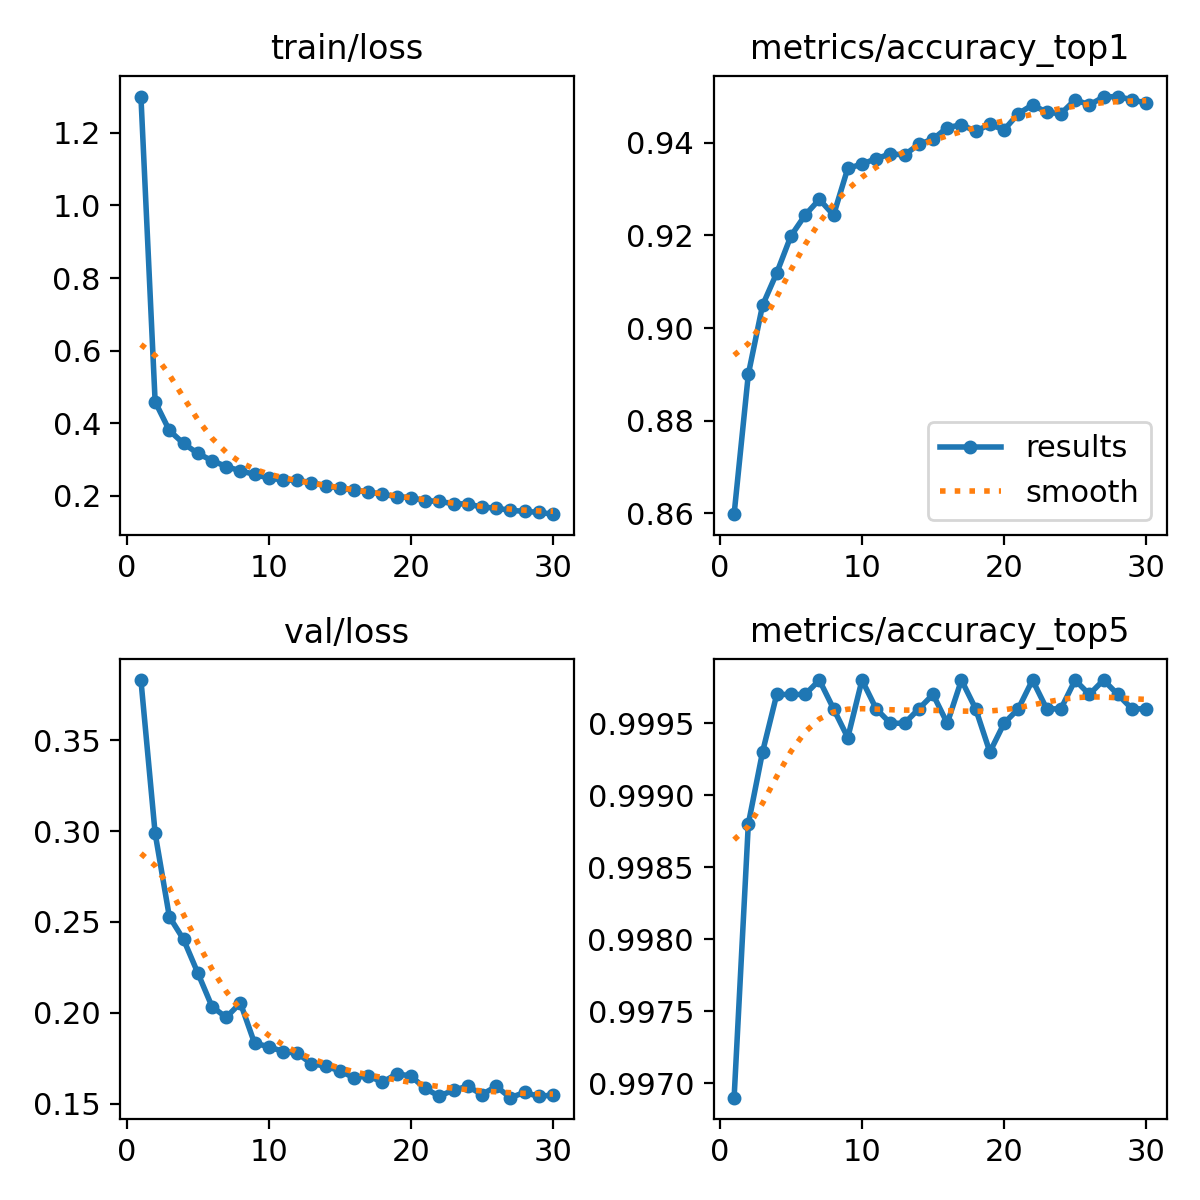


--- 改进版混淆矩阵 (Improved Confusion Matrix) ---


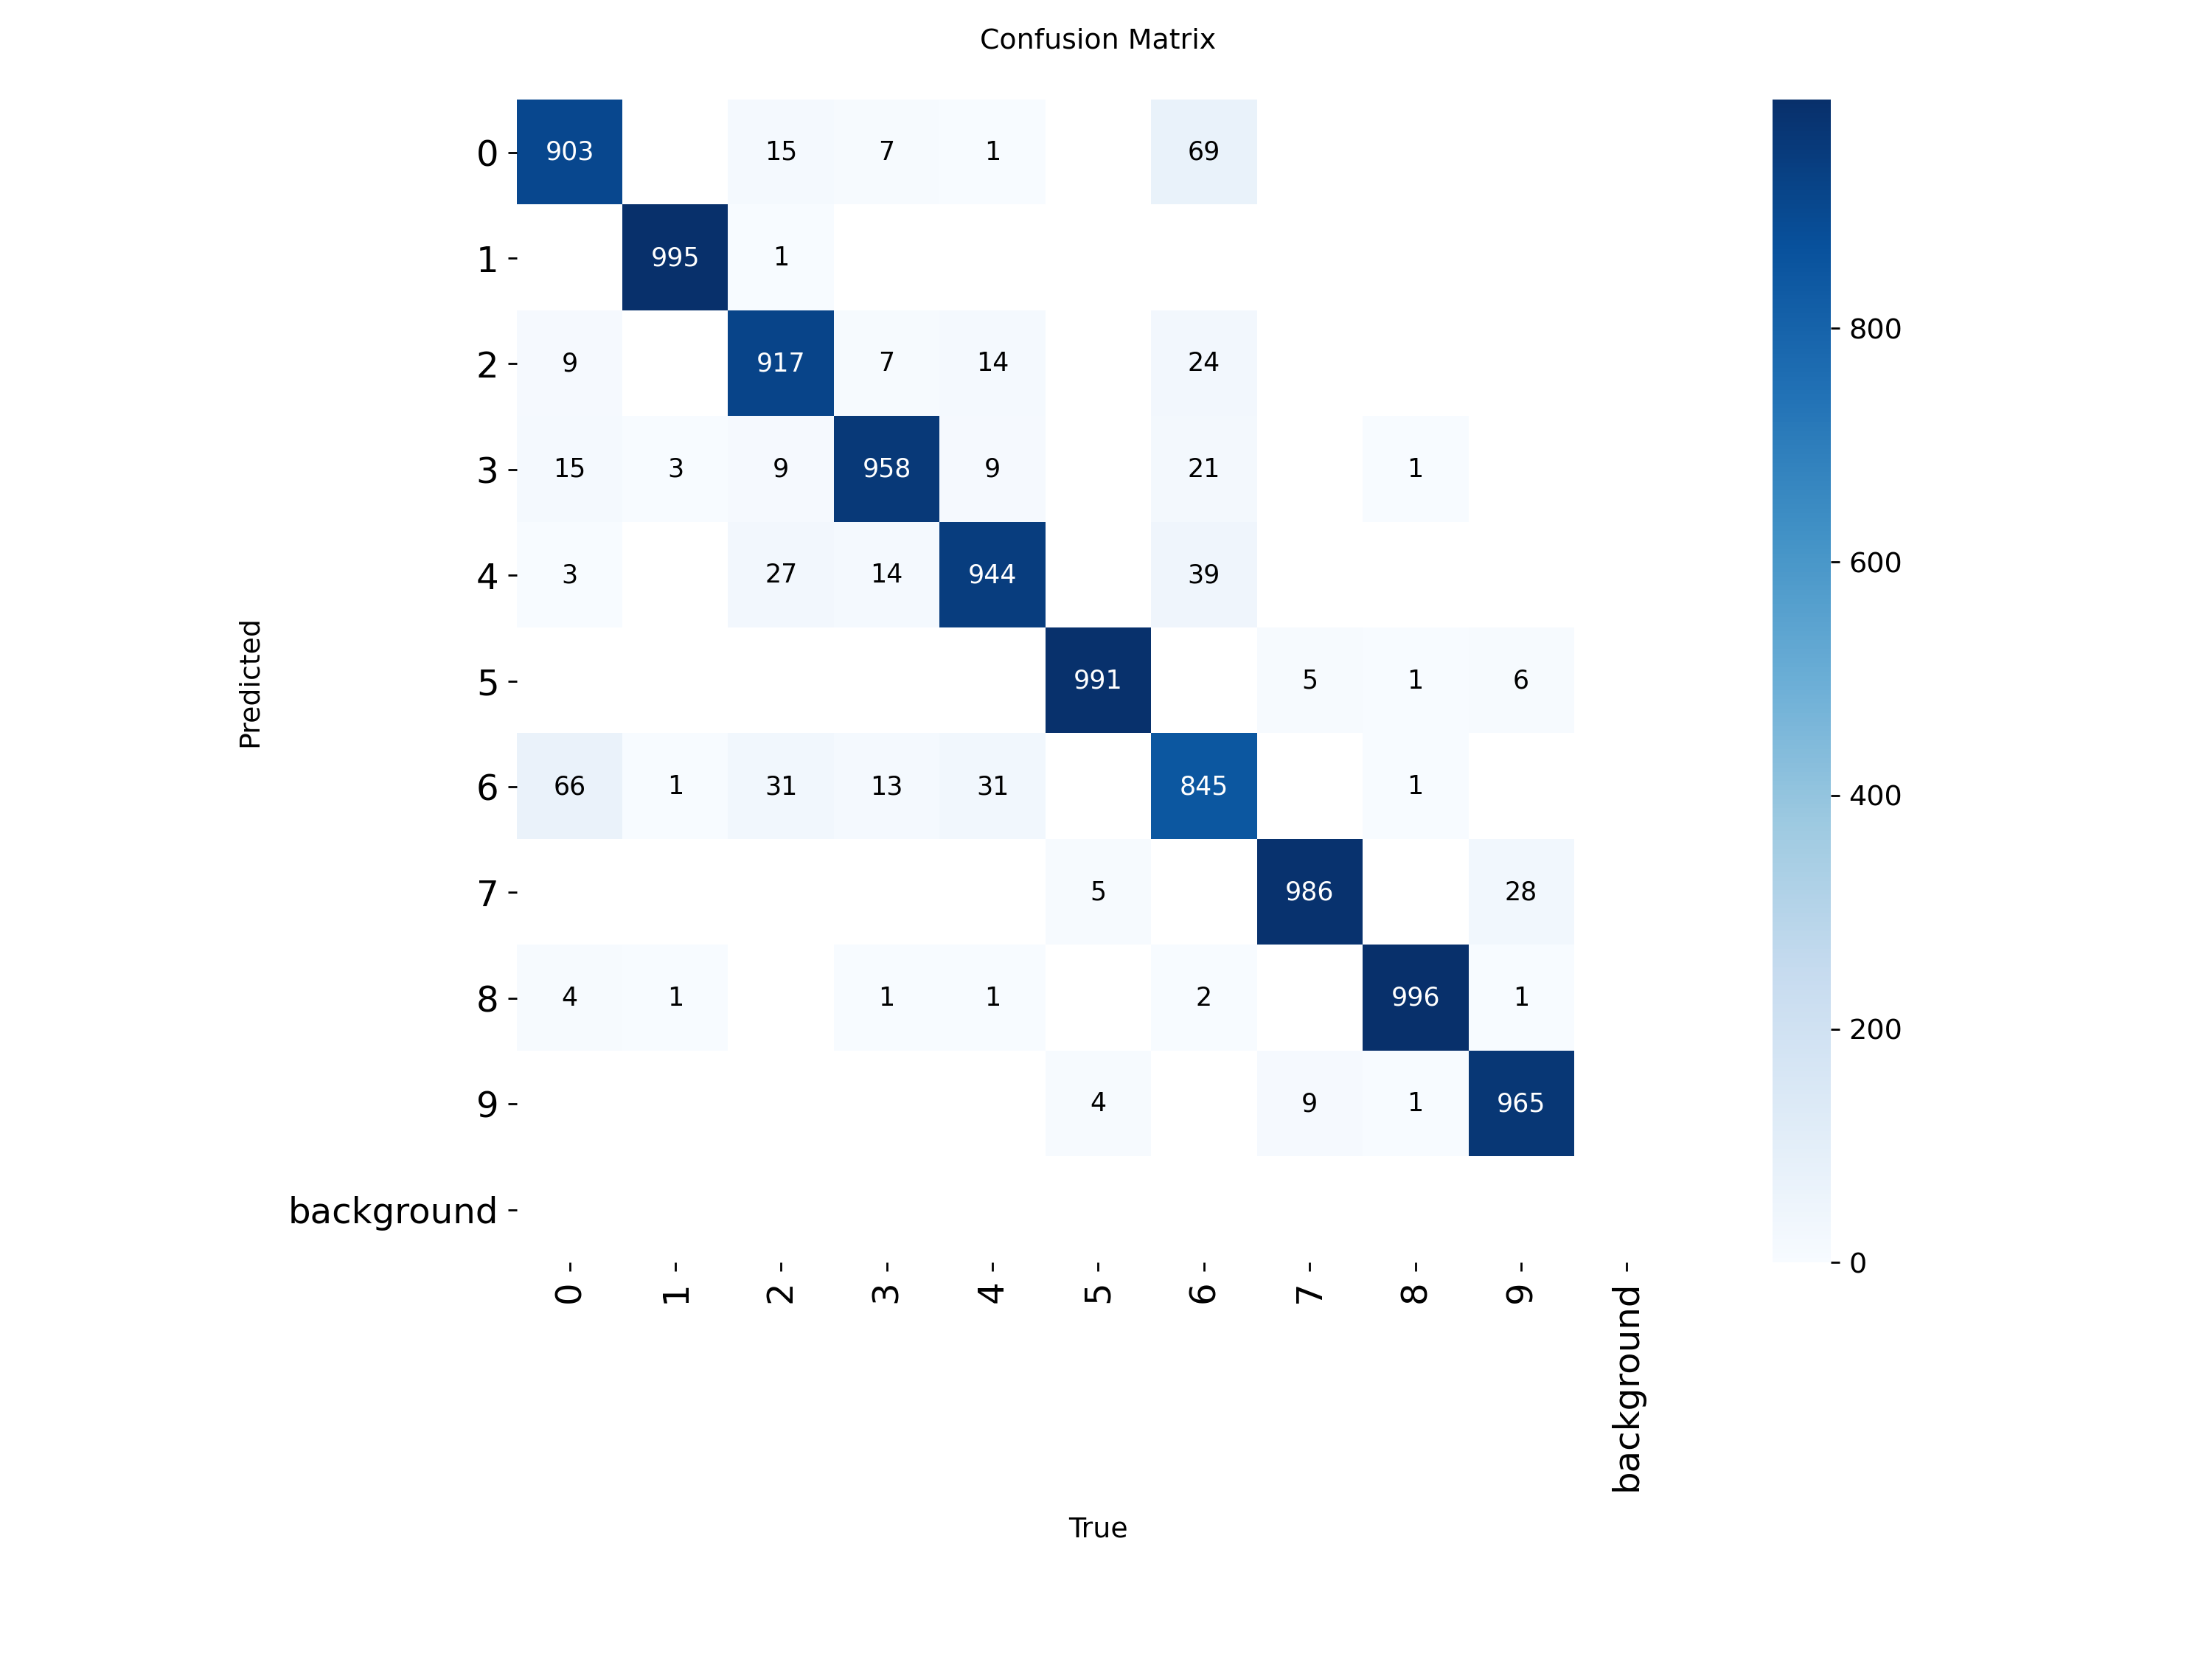

In [13]:
from IPython.display import Image, display
import os

# 改进版 YOLO 自动保存结果的目录
results_dir_improved = '/content/runs/classify/yolo_fmnist_results/run2_improved'

# 显示训练过程的 loss 和 accuracy 曲线
results_img_path_improved = os.path.join(results_dir_improved, 'results.png')
if os.path.exists(results_img_path_improved):
    print("\n--- 改进版训练曲线 (Improved Training Curves) ---")
    display(Image(filename=results_img_path_improved, width=800))
else:
    print(f"未找到文件: {results_img_path_improved}")

# 显示混淆矩阵
cm_img_path_improved = os.path.join(results_dir_improved, 'confusion_matrix.png')
if os.path.exists(cm_img_path_improved):
    print("\n--- 改进版混淆矩阵 (Improved Confusion Matrix) ---")
    display(Image(filename=cm_img_path_improved, width=800))
else:
    print(f"未找到文件: {cm_img_path_improved}")